# Part 3: Perceptron (Rosenblatt, 1957)
## Implementation of the first supervised learning algorithm

First, let's import the necessary libraries. We'll need `numpy` for numerical operations and `matplotlib` for plotting.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Perceptron as SklearnPerceptron
from matplotlib.colors import ListedColormap

Now, let's implement the Perceptron algorithm. The Perceptron is a simple binary classifier. It takes an input, aggregates it (weighted sum), and if the sum is above a certain threshold, it outputs 1, otherwise -1. The weights are updated based on the error.

In [2]:
class Perceptron:
    """Perceptron classifier.

    Parameters
    ------------
    eta : float
      Learning rate (between 0.0 and 1.0)
    n_iter : int
      Passes over the training dataset.
    random_state : int
      Random number generator seed for random weight
      initialization.

    Attributes
    -----------
    w_ : 1d-array
      Weights after fitting.
    errors_ : list
      Number of misclassifications (updates) in each epoch.

    """
    def __init__(self, eta=0.01, n_iter=50, random_state=1):
        self.eta = eta
        self.n_iter = n_iter
        self.random_state = random_state

    def fit(self, X, y):
        """Fit training data.

        Parameters
        ----------
        X : {array-like}, shape = [n_samples, n_features]
          Training vectors, where n_samples is the number of samples and
          n_features is the number of features.
        y : array-like, shape = [n_samples]
          Target values.

        Returns
        -------
        self : object

        """
        rgen = np.random.RandomState(self.random_state)
        self.w_ = rgen.normal(loc=0.0, scale=0.01, size=1 + X.shape[1])
        self.errors_ = []

        for _ in range(self.n_iter):
            errors = 0
            for xi, target in zip(X, y):
                update = self.eta * (target - self.predict(xi))
                self.w_[1:] += update * xi
                self.w_[0] += update
                errors += int(update != 0.0)
            self.errors_.append(errors)
        return self

    def net_input(self, X):
        """Calculate net input"""
        return np.dot(X, self.w_[1:]) + self.w_[0]

    def predict(self, X):
        """Return class label after unit step"""
        return np.where(self.net_input(X) >= 0.0, 1, -1)

## Learning Logic Gates
Now, let's test our Perceptron implementation by teaching it to model various logic gates like AND, OR, NAND, and NOR. We'll create datasets for these gates and then train a Perceptron on each.

In [3]:
# Data for logic gates
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])

# Labels for logic gates
y_and = np.array([-1, -1, -1, 1])
y_or = np.array([-1, 1, 1, 1])
y_nand = np.array([1, 1, 1, -1])
y_nor = np.array([1, -1, -1, -1])

def train_and_test_gate(gate_name, y):
    """
    Trains a Perceptron for a given logic gate and prints the results.
    """
    print(f"--- {gate_name} Gate ---")
    ppn = Perceptron(eta=0.1, n_iter=10)
    ppn.fit(X, y)
    print(f"Weights: {ppn.w_}")
    print(f"Predictions: {ppn.predict(X)}")
    print(f"Errors per epoch: {ppn.errors_}")
    print("\\n")

train_and_test_gate("AND", y_and)
train_and_test_gate("OR", y_or)
train_and_test_gate("NAND", y_nand)
train_and_test_gate("NOR", y_nor)

--- AND Gate ---
Weights: [-0.58375655  0.39388244  0.19471828]
Predictions: [-1 -1 -1  1]
Errors per epoch: [2, 3, 3, 2, 1, 0, 0, 0, 0, 0]
\n
--- OR Gate ---
Weights: [-0.18375655  0.19388244  0.19471828]
Predictions: [-1  1  1  1]
Errors per epoch: [2, 2, 1, 0, 0, 0, 0, 0, 0, 0]
\n
--- NAND Gate ---
Weights: [ 0.41624345 -0.40611756 -0.20528172]
Predictions: [ 1  1  1 -1]
Errors per epoch: [1, 3, 3, 2, 1, 0, 0, 0, 0, 0]
\n
--- NOR Gate ---
Weights: [ 0.01624345 -0.20611756 -0.20528172]
Predictions: [ 1 -1 -1 -1]
Errors per epoch: [1, 2, 1, 0, 0, 0, 0, 0, 0, 0]
\n


## Analysis of XOR Failure
The Perceptron is a linear classifier, which means it can only separate data that is linearly separable. The XOR gate is a classic example of a non-linearly separable problem. Let's try to train our Perceptron on the XOR gate and see what happens.

--- XOR Gate ---
Weights: [ 0.01624345 -0.20611756 -0.00528172]
Predictions: [ 1  1 -1 -1]
Errors per epoch: [3, 3, 4, 4, 4, 4, 4, 4, 4, 4]


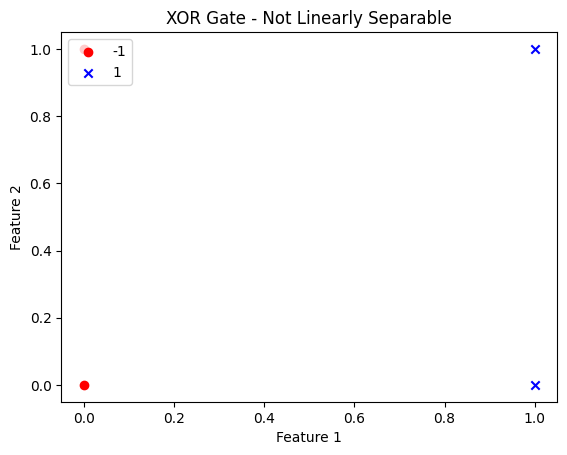

In [4]:
# Data for XOR gate
y_xor = np.array([-1, 1, 1, -1])

print("--- XOR Gate ---")
ppn_xor = Perceptron(eta=0.1, n_iter=10)
ppn_xor.fit(X, y_xor)
print(f"Weights: {ppn_xor.w_}")
print(f"Predictions: {ppn_xor.predict(X)}")
print(f"Errors per epoch: {ppn_xor.errors_}")

# Plotting XOR data
plt.scatter(X[:2, 0], X[:2, 1], color='red', marker='o', label='-1')
plt.scatter(X[2:, 0], X[2:, 1], color='blue', marker='x', label='1')
plt.title('XOR Gate - Not Linearly Separable')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend(loc='upper left')
plt.show()

## Effect of Learning Rate on Convergence
The learning rate (`eta`) is a crucial hyperparameter. A high learning rate can cause the model to overshoot the optimal weights, leading to oscillations and preventing convergence. A very low learning rate can make the training process unnecessarily long. Let's see how different learning rates affect the convergence for the AND gate.

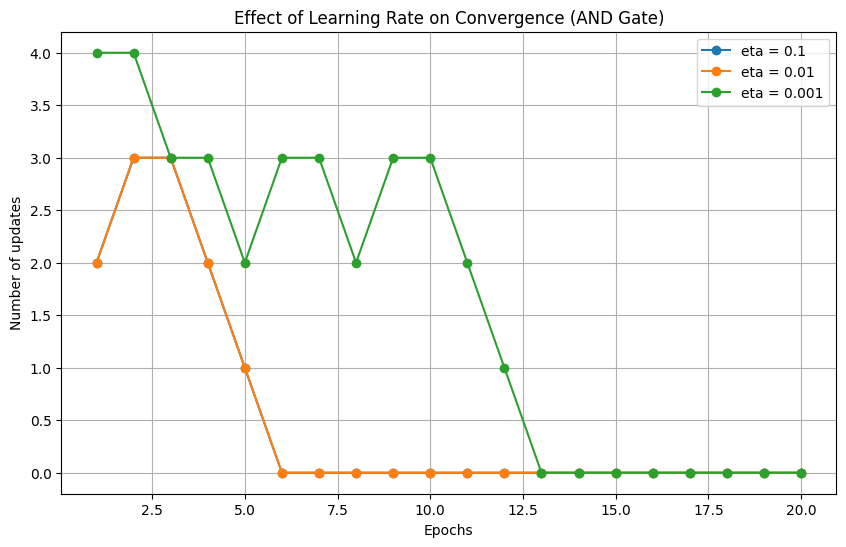

In [5]:
# Learning rates to test
etas = [0.1, 0.01, 0.001]
n_iter = 20

plt.figure(figsize=(10, 6))

for eta in etas:
    ppn = Perceptron(eta=eta, n_iter=n_iter)
    ppn.fit(X, y_and)
    plt.plot(range(1, len(ppn.errors_) + 1), ppn.errors_, marker='o', label=f'eta = {eta}')

plt.title('Effect of Learning Rate on Convergence (AND Gate)')
plt.xlabel('Epochs')
plt.ylabel('Number of updates')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

## Decision Boundary Visualization
The decision boundary is the line or surface that separates the different classes. For a 2D dataset, it's a line. Visualizing the decision boundary helps us understand how the Perceptron is making its decisions. Let's create a function to plot the decision boundary.

C:\Users\chiheb\AppData\Local\Temp\ipykernel_13232\4258753224.py:20: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x=X[y == cl, 0],


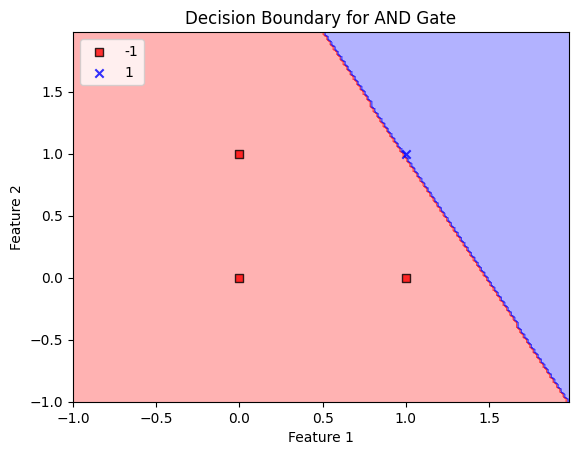

In [6]:
def plot_decision_regions(X, y, classifier, resolution=0.02):
    # setup marker generator and color map
    markers = ('s', 'x', 'o', '^', 'v')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])

    # plot the decision surface
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))
    Z = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    Z = Z.reshape(xx1.shape)
    plt.contourf(xx1, xx2, Z, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    # plot class samples
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0], 
                    y=X[y == cl, 1],
                    alpha=0.8, 
                    c=colors[idx],
                    marker=markers[idx], 
                    label=cl, 
                    edgecolor='black')

# Train a perceptron on the AND gate
ppn_and = Perceptron(eta=0.1, n_iter=10)
ppn_and.fit(X, y_and)

# Plot decision boundary for AND gate
plot_decision_regions(X, y_and, classifier=ppn_and)
plt.title('Decision Boundary for AND Gate')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend(loc='upper left')
plt.show()

## Data Ordering Sensitivity
The Perceptron algorithm is sensitive to the order of the training samples. If the data is not shuffled, the model might take longer to converge or find a different decision boundary. Let's shuffle our AND gate data and retrain the Perceptron to observe this effect.

--- Original AND Gate ---
Weights: [-0.58375655  0.39388244  0.19471828]
\n--- Shuffled AND Gate ---
Weights: [-0.58375655  0.39388244  0.19471828]


C:\Users\chiheb\AppData\Local\Temp\ipykernel_13232\4258753224.py:20: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x=X[y == cl, 0],


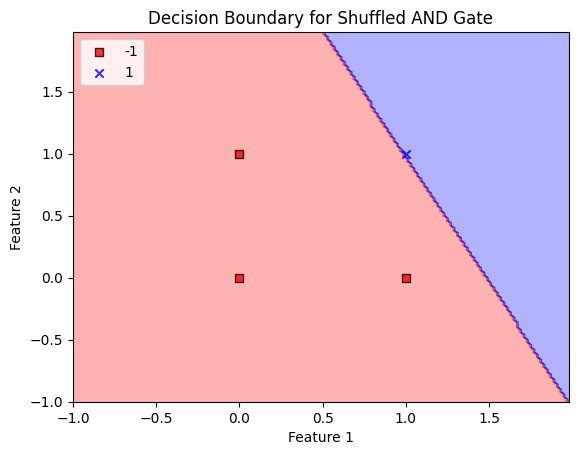

In [7]:
# Shuffle the data
shuffled_indices = np.random.permutation(len(X))
X_shuffled = X[shuffled_indices]
y_and_shuffled = y_and[shuffled_indices]

# Train a new Perceptron on shuffled data
ppn_shuffled = Perceptron(eta=0.1, n_iter=10)
ppn_shuffled.fit(X_shuffled, y_and_shuffled)

print("--- Original AND Gate ---")
print(f"Weights: {ppn_and.w_}")

print("\\n--- Shuffled AND Gate ---")
print(f"Weights: {ppn_shuffled.w_}")

# Plot decision boundary for shuffled AND gate
plot_decision_regions(X_shuffled, y_and_shuffled, classifier=ppn_shuffled)
plt.title('Decision Boundary for Shuffled AND Gate')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend(loc='upper left')
plt.show()

## Voting Perceptron Implementation
The Voting Perceptron is an extension of the standard Perceptron algorithm. Instead of just keeping the final weight vector, it keeps all the weight vectors that are generated during training and how many data points they "survived" for. The prediction is then a weighted vote from all these perceptrons. This can lead to better generalization.

In [8]:
class VotingPerceptron:
    """Voting Perceptron classifier."""
    def __init__(self, eta=0.1, n_iter=50, random_state=1):
        self.eta = eta
        self.n_iter = n_iter
        self.random_state = random_state

    def fit(self, X, y):
        rgen = np.random.RandomState(self.random_state)
        w = rgen.normal(loc=0.0, scale=0.01, size=1 + X.shape[1])
        self.weights_ = [w.copy()]
        self.counts_ = [0]
        
        for _ in range(self.n_iter):
            for xi, target in zip(X, y):
                if (np.dot(xi, w[1:]) + w[0]) * target <= 0:
                    w[1:] += self.eta * target * xi
                    w[0] += self.eta * target
                    self.weights_.append(w.copy())
                    self.counts_.append(1)
                else:
                    self.counts_[-1] += 1
        return self

    def predict(self, X):
        """Return class label after unit step"""
        y_pred = np.zeros(X.shape[0])
        for i in range(X.shape[0]):
            s = np.sum([c * np.sign(np.dot(X[i], w[1:]) + w[0]) for w, c in zip(self.weights_, self.counts_)])
            y_pred[i] = np.sign(s)
        return y_pred

# Train a voting perceptron on the AND gate
vp_and = VotingPerceptron(eta=0.1, n_iter=10)
vp_and.fit(X, y_and)
print("--- Voting Perceptron AND Gate ---")
print(f"Predictions: {vp_and.predict(X)}")
print(f"Number of weight vectors: {len(vp_and.weights_)}")

--- Voting Perceptron AND Gate ---
Predictions: [-1. -1. -1.  1.]
Number of weight vectors: 12


## Application on Iris Dataset
The Iris dataset is a classic dataset in machine learning. It contains 150 samples of iris flowers, each with 4 features: sepal length, sepal width, petal length, and petal width. The flowers belong to one of three species: setosa, versicolor, or virginica.

We will use our Perceptron to classify two of the species (setosa and versicolor) based on two features (sepal length and petal length).

C:\Users\chiheb\AppData\Local\Temp\ipykernel_13232\4258753224.py:20: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x=X[y == cl, 0],


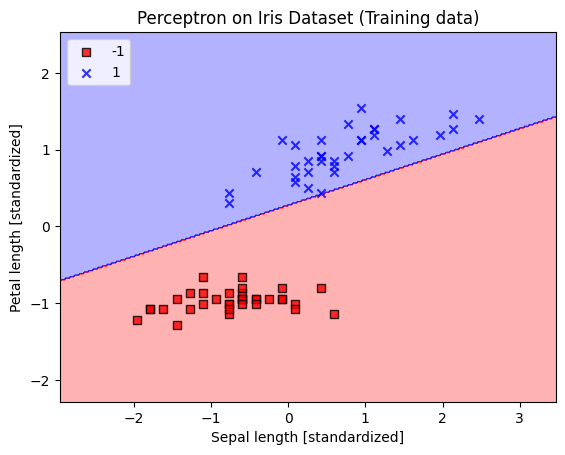

Misclassified samples: 0
Accuracy: 1.0


In [9]:
# Load Iris dataset
iris = load_iris()
X_iris = iris.data[:100, [0, 2]]  # Sepal length and petal length for setosa and versicolor
y_iris = iris.target[:100]
y_iris = np.where(y_iris == 0, -1, 1) # Setosa as -1, versicolor as 1

# Split data into training and testing
X_train, X_test, y_train, y_test = train_test_split(X_iris, y_iris, test_size=0.3, random_state=1, stratify=y_iris)

# Scale features
sc = StandardScaler()
sc.fit(X_train)
X_train_std = sc.transform(X_train)
X_test_std = sc.transform(X_test)

# Train Perceptron
ppn_iris = Perceptron(eta=0.01, n_iter=20)
ppn_iris.fit(X_train_std, y_train)

# Plot decision boundary
plot_decision_regions(X_train_std, y_train, classifier=ppn_iris)
plt.title('Perceptron on Iris Dataset (Training data)')
plt.xlabel('Sepal length [standardized]')
plt.ylabel('Petal length [standardized]')
plt.legend(loc='upper left')
plt.show()

# Evaluate on test data
y_pred = ppn_iris.predict(X_test_std)
print(f'Misclassified samples: {(y_test != y_pred).sum()}')
from sklearn.metrics import accuracy_score
print(f'Accuracy: {accuracy_score(y_test, y_pred)}')

## Comparison with scikit-learn
Scikit-learn provides a well-optimized and robust implementation of the Perceptron algorithm. Let's use it on our Iris dataset and compare the results with our own implementation.

C:\Users\chiheb\AppData\Local\Temp\ipykernel_13232\4258753224.py:20: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x=X[y == cl, 0],


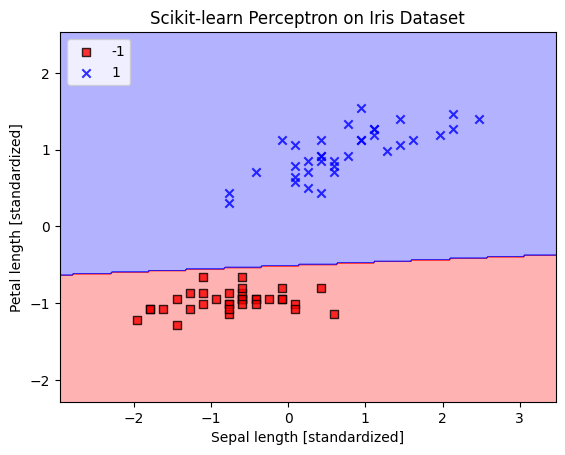

Misclassified samples (scikit-learn): 0
Accuracy (scikit-learn): 1.0


In [10]:
# Train scikit-learn Perceptron
sklearn_ppn = SklearnPerceptron(eta0=0.01, max_iter=20, random_state=1)
sklearn_ppn.fit(X_train_std, y_train)

# Plot decision boundary
plot_decision_regions(X_train_std, y_train, classifier=sklearn_ppn)
plt.title('Scikit-learn Perceptron on Iris Dataset')
plt.xlabel('Sepal length [standardized]')
plt.ylabel('Petal length [standardized]')
plt.legend(loc='upper left')
plt.show()

# Evaluate on test data
y_pred_sklearn = sklearn_ppn.predict(X_test_std)
print(f'Misclassified samples (scikit-learn): {(y_test != y_pred_sklearn).sum()}')
print(f'Accuracy (scikit-learn): {accuracy_score(y_test, y_pred_sklearn)}')